In [20]:
%pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


DATA LOADING 

In [2]:
# Cell 25: Import Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Set figure size default
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Visualization libraries imported successfully!")

✅ Visualization libraries imported successfully!


In [3]:
# Cell 1: Setup
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set display options to see everything
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [23]:
# Cell 2: Load Data
file_path = r'C:\Users\Usman Ahmad\Desktop\vs code\Datascience- project\Walmart.csv'

# Load with date parsing
df = pd.read_csv(file_path, parse_dates=['date'])

print(f"✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully!
📊 Shape: 10051 rows × 11 columns


UNDERSTANDING THE DATA AND CLEANING DATASET

In [24]:
# Cell 3: First and Last Rows
print("=" * 80)
print("FIRST 5 ROWS:")
print("=" * 80)
display(df.head())

print("\n" + "=" * 80)
print("LAST 5 ROWS:")
print("=" * 80)
display(df.tail())

FIRST 5 ROWS:


,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,$74.69,7.0,2019-05-01,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,$15.28,5.0,2019-08-03,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,$46.33,7.0,2019-03-03,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,$58.22,8.0,2019-01-27,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,$86.31,7.0,2019-08-02,10:37:00,Ewallet,5.3,0.48



LAST 5 ROWS:


,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
10046,9996,WALM056,Rowlett,Fashion accessories,$37,3.0,2023-03-08,10:10:00,Cash,3.0,0.33
10047,9997,WALM030,Richardson,Home and lifestyle,$58,2.0,2021-02-22,14:20:00,Cash,7.0,0.48
10048,9998,WALM050,Victoria,Fashion accessories,$52,3.0,2023-06-15,16:00:00,Credit card,4.0,0.48
10049,9999,WALM032,Tyler,Home and lifestyle,$79,2.0,2021-02-25,12:25:00,Cash,7.0,0.48
10050,10000,WALM069,Rockwall,Fashion accessories,$62,3.0,2020-09-26,9:48:00,Cash,3.0,0.33


In [25]:
# Cell 4: Data Types and Info
print("=" * 80)
print("COLUMN INFORMATION:")
print("=" * 80)
print(df.info())

print("\n" + "=" * 80)
print("COLUMN NAMES AND DATA TYPES:")
print("=" * 80)
print(df.dtypes)

COLUMN INFORMATION:
<class 'pandas.DataFrame'>
RangeIndex: 10051 entries, 0 to 10050
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_id      10051 non-null  int64         
 1   Branch          10051 non-null  str           
 2   City            10051 non-null  str           
 3   category        10051 non-null  str           
 4   unit_price      10020 non-null  str           
 5   quantity        10020 non-null  float64       
 6   date            10051 non-null  datetime64[us]
 7   time            10051 non-null  str           
 8   payment_method  10051 non-null  str           
 9   rating          10051 non-null  float64       
 10  profit_margin   10051 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(6)
memory usage: 863.9 KB
None

COLUMN NAMES AND DATA TYPES:
invoice_id                 int64
Branch                       str
City                      

In [26]:

# 1. Load data
df = pd.read_csv(r'C:\Users\Usman Ahmad\Desktop\vs code\Datascience- project\Walmart.csv', parse_dates=['date'])

# 2. Clean unit_price (remove $ and convert to float)
df['unit_price'] = df['unit_price'].str.replace('$', '').astype(float)

# 3. Impute missing values (use median for both)
df['unit_price'] = df['unit_price'].fillna(df['unit_price'].mean())
df['quantity'] = df['quantity'].fillna(df['quantity'].mean())

# 4. Convert time to datetime
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time

# 5. Remove duplicates (keep first occurrence)
df = df.drop_duplicates()

# 6. Verify changes
print(f"✅ Cleaned: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"✅ Missing values: {df.isnull().sum().sum()}")
print(f"✅ Unit_price dtype: {df['unit_price'].dtype}")

✅ Cleaned: 10000 rows, 11 columns
✅ Missing values: 0
✅ Unit_price dtype: float64


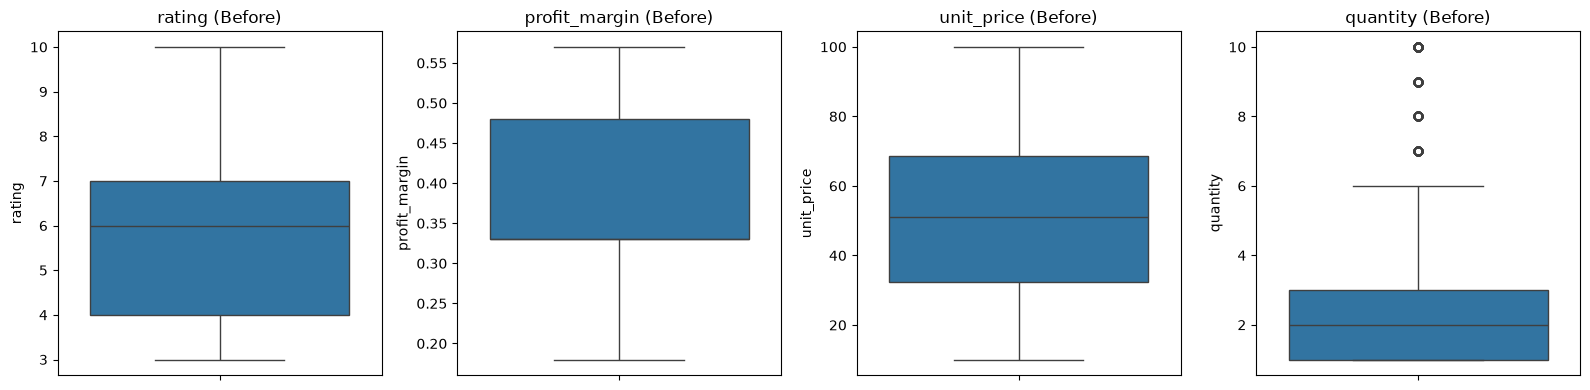

✅ Outliers capped using IQR method


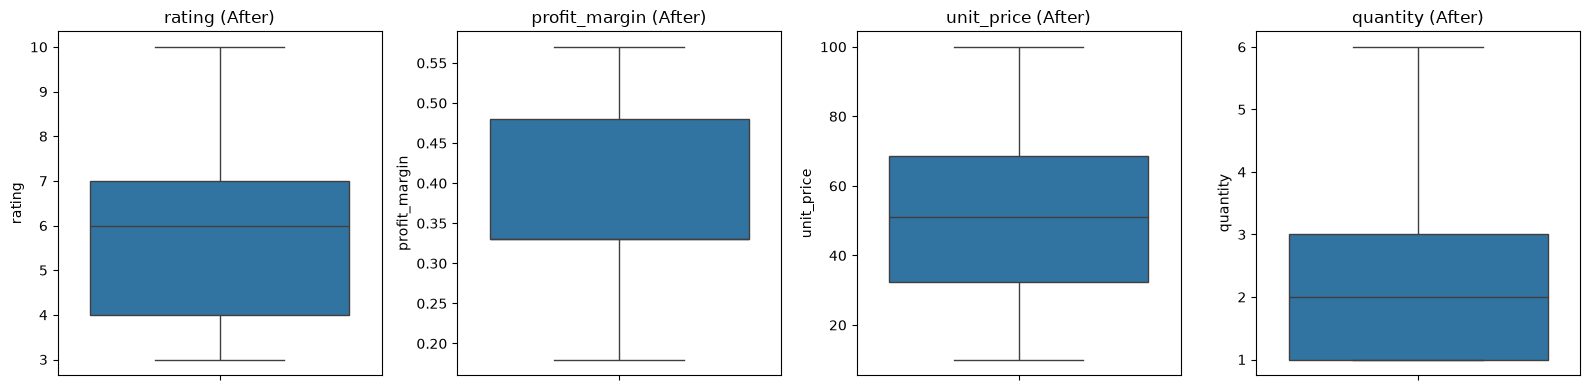

In [27]:
from scipy import stats

# Numerical columns
num_cols = ['rating', 'profit_margin', 'unit_price', 'quantity']

# 1. Boxplot BEFORE capping
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'{col} (Before)')
plt.tight_layout()
plt.show()

# 2. Cap outliers using IQR method
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    return df

# Apply capping
for col in num_cols:
    df = cap_outliers_iqr(df, col)

print("✅ Outliers capped using IQR method")

# 3. Boxplot AFTER capping
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'{col} (After)')
plt.tight_layout()
plt.show()

In [28]:
# Extract date components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week
df['day'] = df['date'].dt.day
df['quarter'] = df['date'].dt.quarter

# Optional: Add day name and week number
df['day_name'] = df['date'].dt.day_name()
df['weekday'] = df['date'].dt.weekday  # Monday=0, Sunday=6

# Verify
print("✅ New date features added:")
print(df[['date', 'year', 'month', 'week', 'day', 'quarter']].head())

✅ New date features added:
        date  year  month  week  day  quarter
0 2019-05-01  2019      5    18    1        2
1 2019-08-03  2019      8    31    3        3
2 2019-03-03  2019      3     9    3        1
3 2019-01-27  2019      1     4   27        1
4 2019-08-02  2019      8    31    2        3


In [29]:
#  Drop invoice_id if not needed
df = df.drop(['invoice_id'], axis=1)


In [30]:
# Save with full path
df_clean.to_csv(r'C:\Users\Usman Ahmad\Desktop\vs code\Datascience- project\Walmart_Cleaned.csv', index=False)
print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


 EDA 

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Use your cleaned dataframe
df = df_clean.copy()

# Create revenue column
df['revenue'] = df['unit_price'] * df['quantity']

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS - WALMART SALES")
print("=" * 60)
print(f"📊 Total Records: {len(df):,}")
print(f"💰 Total Revenue: ${df['revenue'].sum():,.2f}")
print(f"📈 Avg Rating: {df['rating'].mean():.2f}/10")

EXPLORATORY DATA ANALYSIS - WALMART SALES
📊 Total Records: 10,000
💰 Total Revenue: $1,155,753.96
📈 Avg Rating: 5.83/10


SALES OVER TIME 

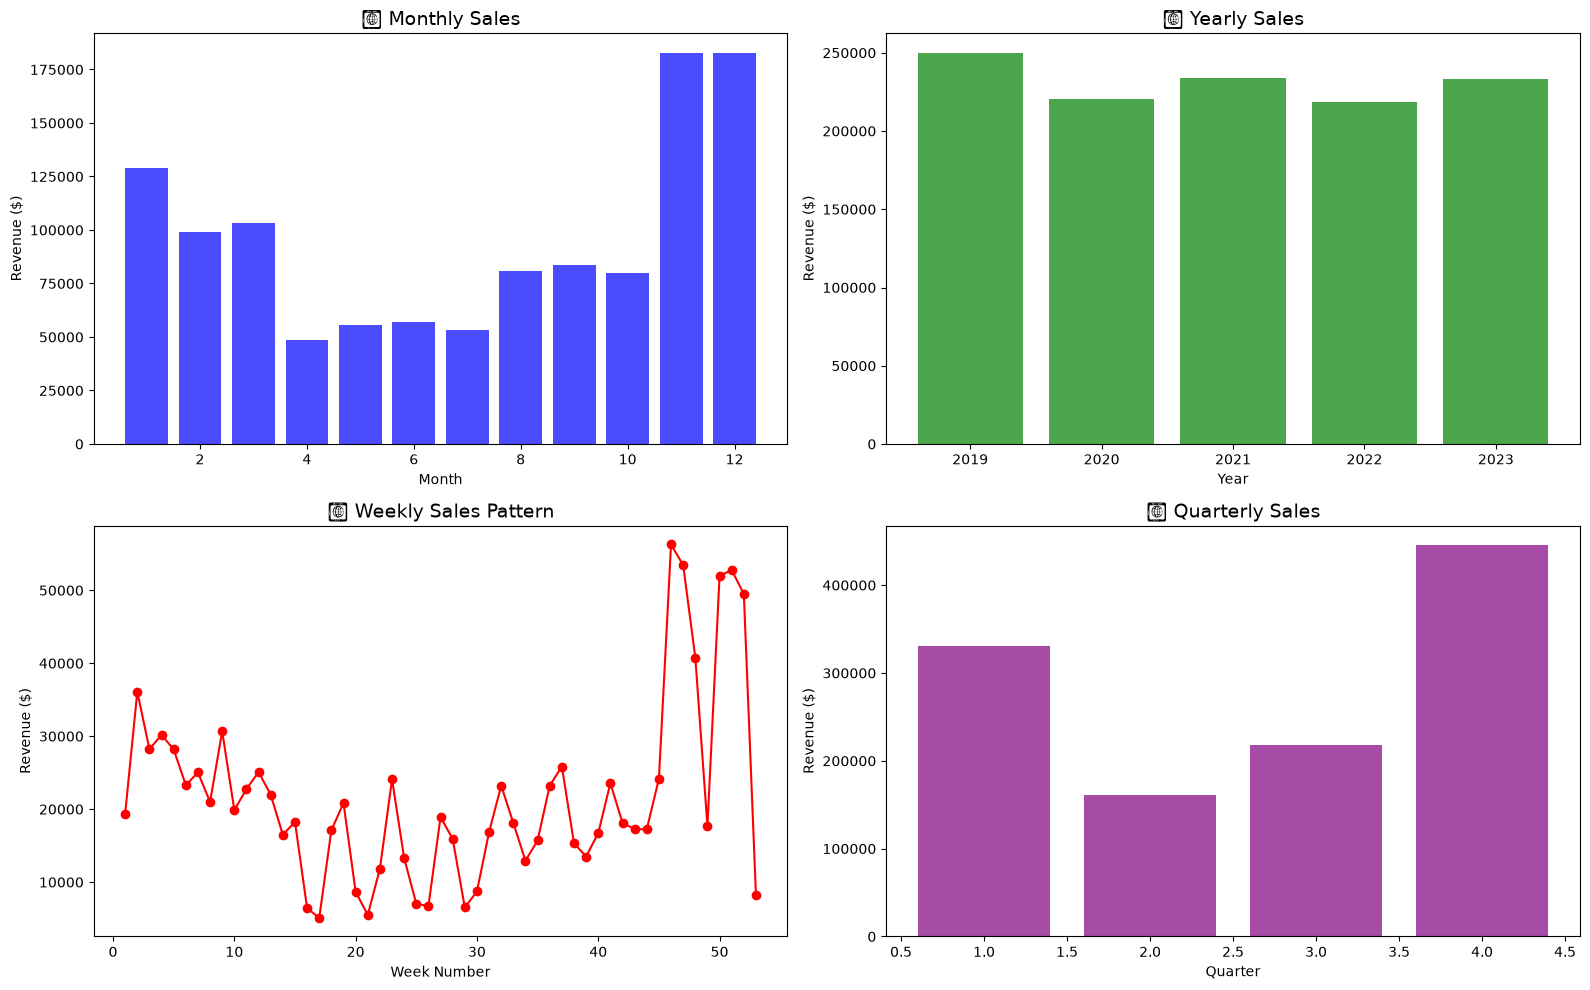

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Monthly Sales
monthly_sales = df.groupby('month')['revenue'].sum().reset_index()
axes[0,0].bar(monthly_sales['month'], monthly_sales['revenue'], color='blue', alpha=0.7)
axes[0,0].set_title('📊 Monthly Sales', fontsize=14)
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Revenue ($)')

# Yearly Sales
yearly_sales = df.groupby('year')['revenue'].sum().reset_index()
axes[0,1].bar(yearly_sales['year'], yearly_sales['revenue'], color='green', alpha=0.7)
axes[0,1].set_title('📊 Yearly Sales', fontsize=14)
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Revenue ($)')

# Weekly Sales
weekly_sales = df.groupby('week')['revenue'].sum().reset_index()
axes[1,0].plot(weekly_sales['week'], weekly_sales['revenue'], color='red', marker='o')
axes[1,0].set_title('📉 Weekly Sales Pattern', fontsize=14)
axes[1,0].set_xlabel('Week Number')
axes[1,0].set_ylabel('Revenue ($)')

# Quarterly Sales
quarterly_sales = df.groupby('quarter')['revenue'].sum().reset_index()
axes[1,1].bar(quarterly_sales['quarter'], quarterly_sales['revenue'], color='purple', alpha=0.7)
axes[1,1].set_title('📊 Quarterly Sales', fontsize=14)
axes[1,1].set_xlabel('Quarter')
axes[1,1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

BRANCH PERFORMANCE

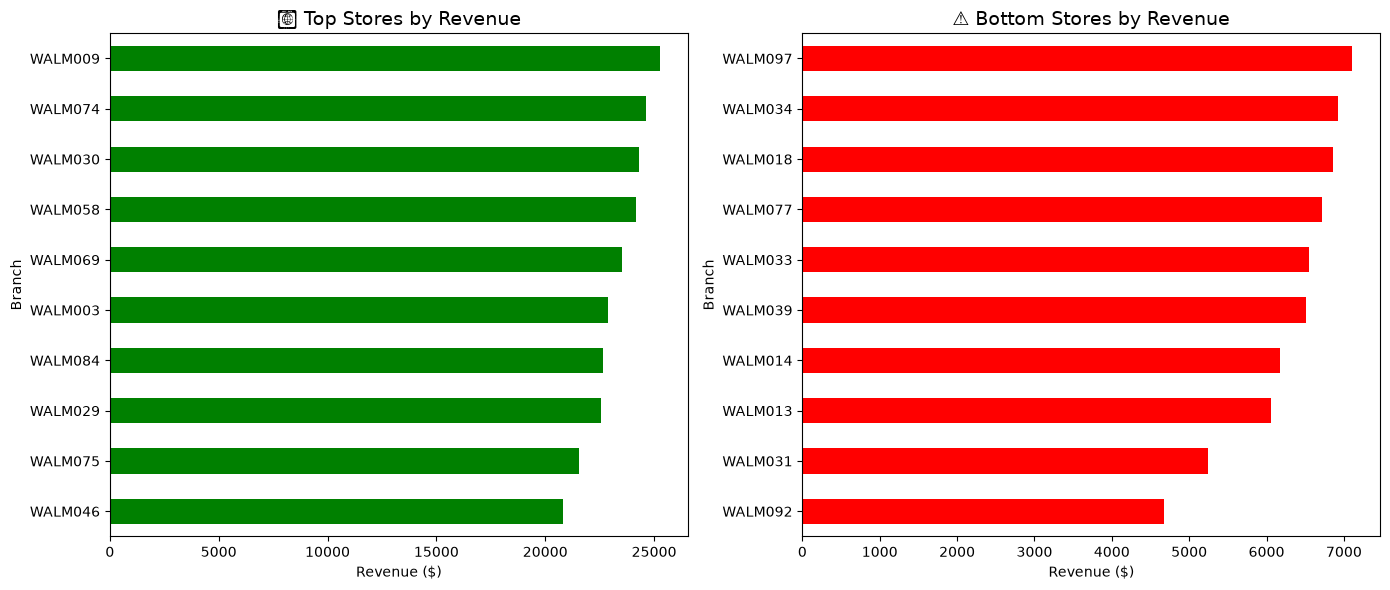


🏆 TOP 5 BRANCHES:
              revenue    quantity    rating
Branch                                     
WALM009  25271.224952  493.706986  5.335443
WALM074  24633.720000  459.000000  5.176190
WALM030  24290.577476  485.353493  5.414348
WALM058  24151.660000  487.000000  5.298745
WALM069  23507.467476  491.353493  5.350673

⚠️ BOTTOM 5 BRANCHES:
         revenue  quantity    rating
Branch                              
WALM039  6507.24     148.0  6.450847
WALM014  6175.79     118.0  6.542308
WALM013  6062.52     132.0  6.291228
WALM031  5249.48     125.0  6.244643
WALM092  4667.92     108.0  6.527451


In [33]:
# Branch Performance
branch_performance = df.groupby('Branch').agg({
    'revenue': 'sum',
    'quantity': 'sum',
    'rating': 'mean'
}).sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top Stores
branch_performance['revenue'].sort_values(ascending=True).tail(10).plot(
    kind='barh', ax=axes[0], color='green')
axes[0].set_title('🏆 Top Stores by Revenue', fontsize=14)
axes[0].set_xlabel('Revenue ($)')

# Worst Stores
branch_performance['revenue'].sort_values(ascending=True).head(10).plot(
    kind='barh', ax=axes[1], color='red')
axes[1].set_title('⚠️ Bottom Stores by Revenue', fontsize=14)
axes[1].set_xlabel('Revenue ($)')

plt.tight_layout()
plt.show()

print("\n🏆 TOP 5 BRANCHES:")
print(branch_performance.head())
print("\n⚠️ BOTTOM 5 BRANCHES:")
print(branch_performance.tail())

CATEGORY ANALYSIS

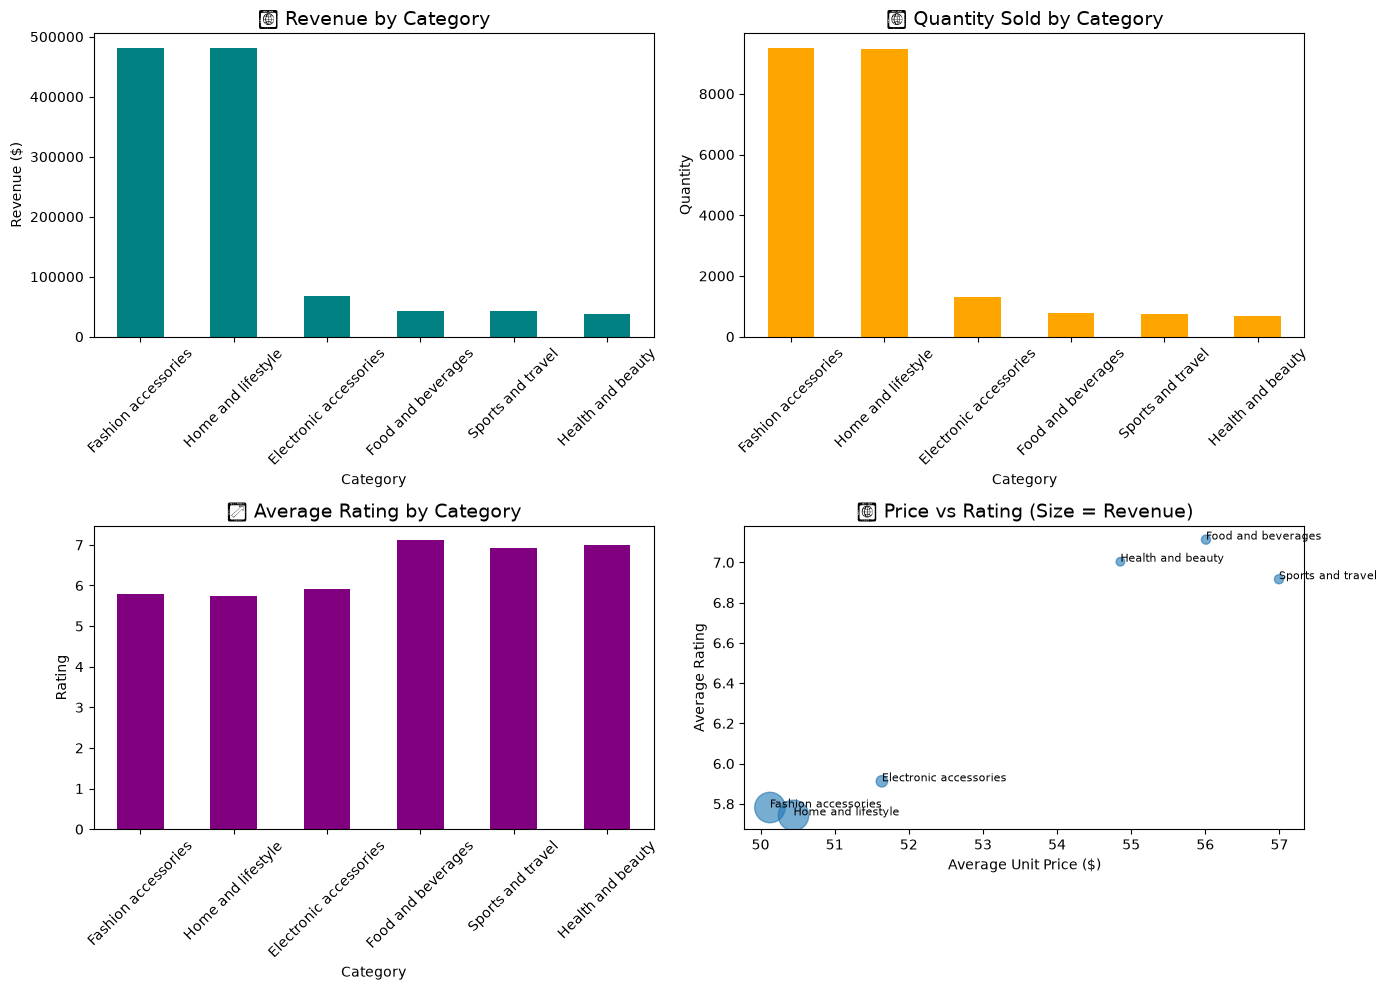


📊 CATEGORY PERFORMANCE:
                              revenue     quantity  unit_price    rating
category                                                                
Fashion accessories     481584.552137  9517.302395   50.126247  5.781946
Home and lifestyle      481518.499613  9479.655888   50.444619  5.742725
Electronic accessories   67915.590000  1308.000000   51.636683  5.912172
Food and beverages       43536.900000   779.000000   56.008851  7.113218
Sports and travel        42813.410000   750.000000   56.993253  6.916265
Health and beauty        38385.010000   698.000000   54.854474  7.003289


In [34]:
# Category Performance
category_perf = df.groupby('category').agg({
    'revenue': 'sum',
    'quantity': 'sum',
    'unit_price': 'mean',
    'rating': 'mean'
}).sort_values('revenue', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Revenue by Category
category_perf['revenue'].plot(kind='bar', ax=axes[0,0], color='teal')
axes[0,0].set_title('💰 Revenue by Category', fontsize=14)
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].tick_params(axis='x', rotation=45)

# Quantity by Category
category_perf['quantity'].plot(kind='bar', ax=axes[0,1], color='orange')
axes[0,1].set_title('📦 Quantity Sold by Category', fontsize=14)
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Quantity')
axes[0,1].tick_params(axis='x', rotation=45)

# Rating by Category
category_perf['rating'].plot(kind='bar', ax=axes[1,0], color='purple')
axes[1,0].set_title('⭐ Average Rating by Category', fontsize=14)
axes[1,0].set_xlabel('Category')
axes[1,0].set_ylabel('Rating')
axes[1,0].tick_params(axis='x', rotation=45)

# Price vs Rating
ax = axes[1,1]
scatter = ax.scatter(category_perf['unit_price'], category_perf['rating'], 
                    s=category_perf['revenue']/1000, alpha=0.6)
ax.set_title('💵 Price vs Rating (Size = Revenue)', fontsize=14)
ax.set_xlabel('Average Unit Price ($)')
ax.set_ylabel('Average Rating')
for idx, row in category_perf.iterrows():
    ax.annotate(idx, (row['unit_price'], row['rating']), fontsize=8)

plt.tight_layout()
plt.show()

print("\n📊 CATEGORY PERFORMANCE:")
print(category_perf)

PAYMENT METHOD ANALYSIS

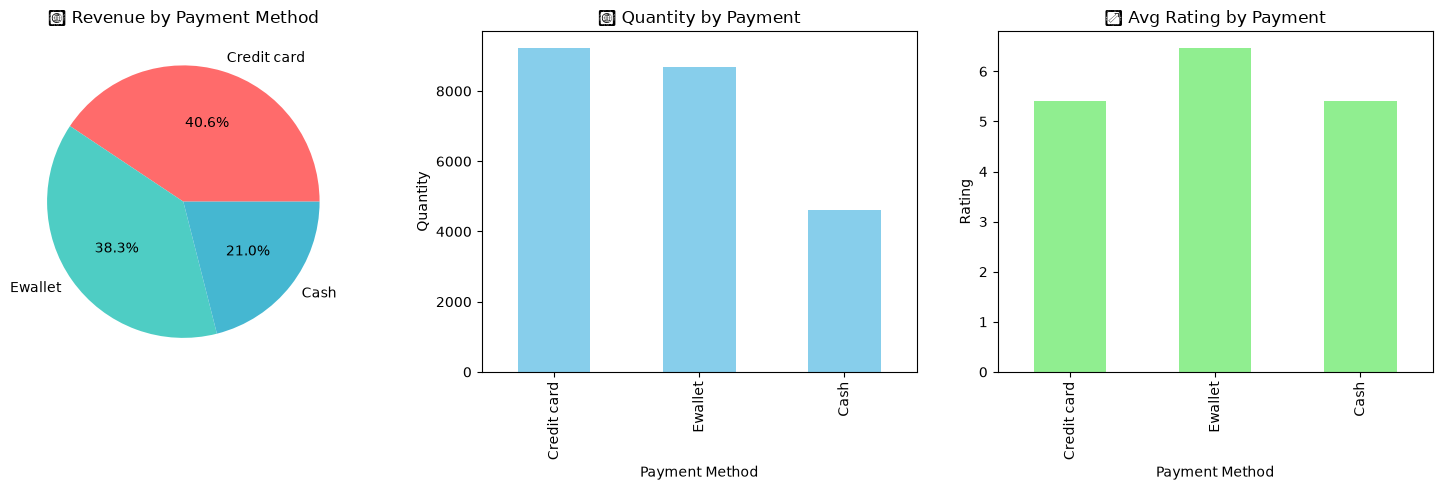

In [35]:
# Payment Analysis
payment_analysis = df.groupby('payment_method').agg({
    'revenue': 'sum',
    'quantity': 'sum',
    'rating': 'mean'
}).sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Revenue by Payment
payment_analysis['revenue'].plot(kind='pie', ax=axes[0], autopct='%1.1f%%', 
                                  colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('💳 Revenue by Payment Method')

# Quantity by Payment
payment_analysis['quantity'].plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('📦 Quantity by Payment')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Quantity')

# Rating by Payment
payment_analysis['rating'].plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('⭐ Avg Rating by Payment')
axes[2].set_xlabel('Payment Method')
axes[2].set_ylabel('Rating')

plt.tight_layout()
plt.show()

CORRELATION & DISTRIBUTION

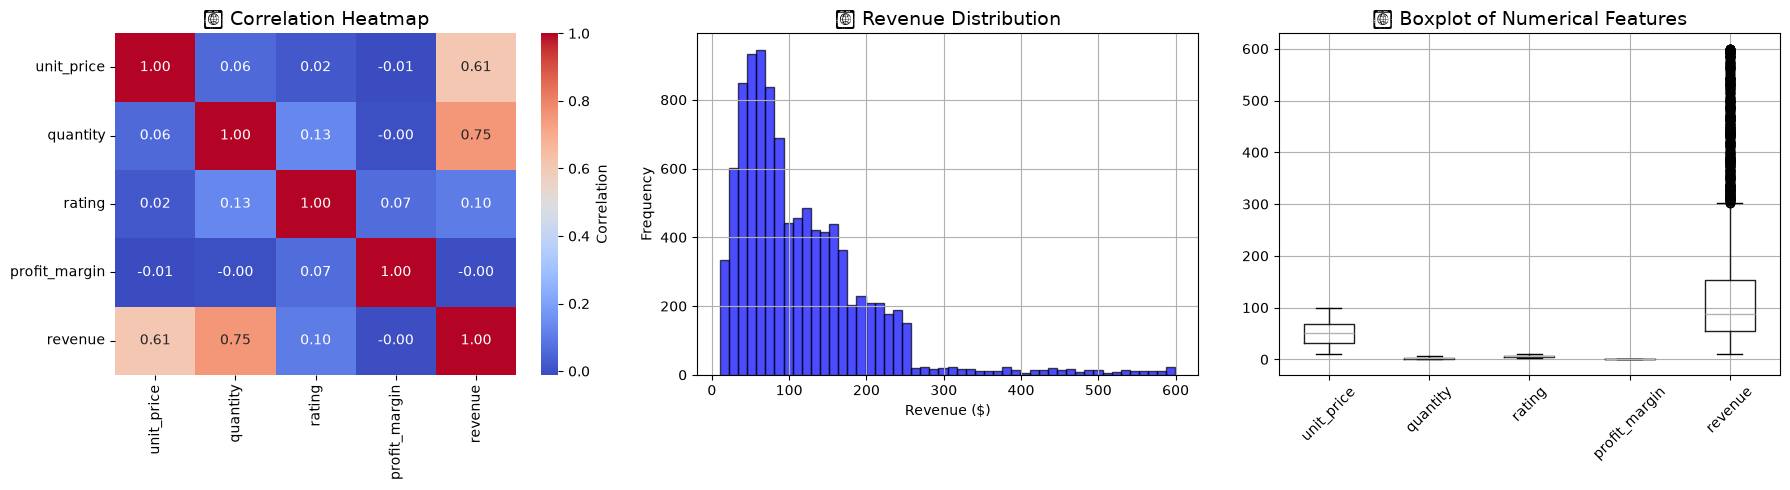

In [36]:
# Numerical features correlation
num_cols = ['unit_price', 'quantity', 'rating', 'profit_margin', 'revenue']
correlation_matrix = df[num_cols].corr()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Correlation Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('📊 Correlation Heatmap', fontsize=14)

# Distribution of Revenue
df['revenue'].hist(bins=50, ax=axes[1], color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title('💰 Revenue Distribution', fontsize=14)
axes[1].set_xlabel('Revenue ($)')
axes[1].set_ylabel('Frequency')

# Boxplot of Numerical Features
df[num_cols].boxplot(ax=axes[2])
axes[2].set_title('📦 Boxplot of Numerical Features', fontsize=14)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

 RATING ANALYSIS

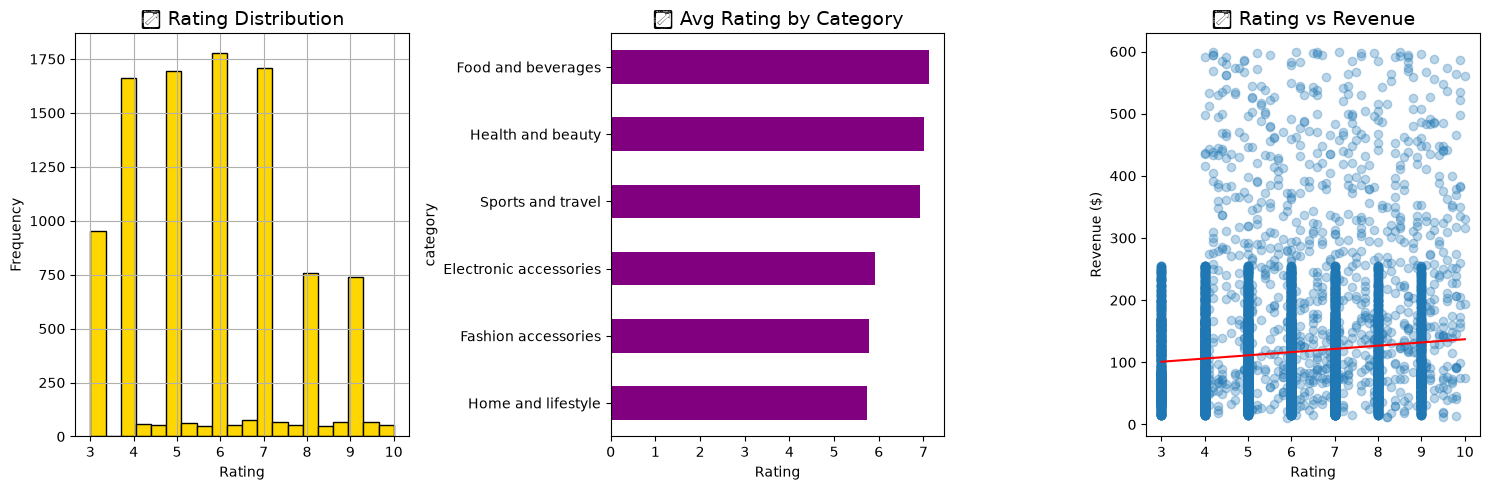

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Rating Distribution
df['rating'].hist(bins=20, ax=axes[0], color='gold', edgecolor='black')
axes[0].set_title('⭐ Rating Distribution', fontsize=14)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')

# Rating by Category
df.groupby('category')['rating'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='purple')
axes[1].set_title('⭐ Avg Rating by Category', fontsize=14)
axes[1].set_xlabel('Rating')

# Rating vs Revenue
axes[2].scatter(df['rating'], df['revenue'], alpha=0.3)
axes[2].set_title('⭐ Rating vs Revenue', fontsize=14)
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Revenue ($)')
z = np.polyfit(df['rating'], df['revenue'], 1)
p = np.poly1d(z)
axes[2].plot(df['rating'].sort_values(), p(df['rating'].sort_values()), 'red')

plt.tight_layout()
plt.show()

KEY INSIGHTS SUMMARY

In [38]:
# Generate summary statistics with error handling
print("\n" + "=" * 60)
print("📊 KEY BUSINESS INSIGHTS")
print("=" * 60)

print("\n💰 REVENUE INSIGHTS:")
print(f"  Total Revenue: ${df['revenue'].sum():,.2f}")
print(f"  Average Revenue: ${df['revenue'].mean():,.2f}")

# Category Performance
category_perf = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
print(f"  Top Category: {category_perf.index[0]} (${category_perf.iloc[0]:,.2f})")
print(f"  Worst Category: {category_perf.index[-1]} (${category_perf.iloc[-1]:,.2f})")

# Branch Performance
branch_performance = df.groupby('Branch')['revenue'].sum().sort_values(ascending=False)
print(f"  Top Branch: {branch_performance.index[0]} (${branch_performance.iloc[0]:,.2f})")
print(f"  Worst Branch: {branch_performance.index[-1]} (${branch_performance.iloc[-1]:,.2f})")

print("\n⭐ CUSTOMER INSIGHTS:")
print(f"  Average Rating: {df['rating'].mean():.2f}/10")
print(f"  Most Common Payment: {df['payment_method'].mode()[0]}")
print(f"  Most Popular Category: {df['category'].mode()[0]}")

print("\n📈 TRENDS:")
# Monthly Performance
monthly_perf = df.groupby('month')['revenue'].mean()
print(f"  Best Month: {monthly_perf.idxmax()} (${monthly_perf.max():,.2f})")
print(f"  Worst Month: {monthly_perf.idxmin()} (${monthly_perf.min():,.2f})")

# Weekly Performance
weekly_perf = df.groupby('week')['revenue'].sum()
print(f"  Best Week: {weekly_perf.idxmax()} (${weekly_perf.max():,.2f})")

# City Performance
city_performance = df.groupby('City')['revenue'].sum().sort_values(ascending=False)
print(f"  Top City: {city_performance.index[0]} (${city_performance.iloc[0]:,.2f})")

print("\n📦 PRODUCT INSIGHTS:")
print(f"  Total Items Sold: {df['quantity'].sum():,.0f}")
print(f"  Average Unit Price: ${df['unit_price'].mean():,.2f}")
print(f"  Average Profit Margin: {df['profit_margin'].mean():.2%}")


📊 KEY BUSINESS INSIGHTS

💰 REVENUE INSIGHTS:
  Total Revenue: $1,155,753.96
  Average Revenue: $115.58
  Top Category: Fashion accessories ($481,584.55)
  Worst Category: Health and beauty ($38,385.01)
  Top Branch: WALM009 ($25,271.22)
  Worst Branch: WALM092 ($4,667.92)

⭐ CUSTOMER INSIGHTS:
  Average Rating: 5.83/10
  Most Common Payment: Credit card
  Most Popular Category: Fashion accessories

📈 TRENDS:
  Best Month: 2 ($148.51)
  Worst Month: 11 ($102.27)
  Best Week: 46 ($56,276.00)
  Top City: Weslaco ($44,822.32)

📦 PRODUCT INSIGHTS:
  Total Items Sold: 22,532
  Average Unit Price: $50.62
  Average Profit Margin: 39.38%


In [39]:
# Comprehensive summary
print("\n" + "=" * 60)
print("📊 COMPREHENSIVE BUSINESS INSIGHTS")
print("=" * 60)

# Revenue Metrics
print("\n💰 REVENUE METRICS:")
print(f"  Total Revenue: ${df['revenue'].sum():,.2f}")
print(f"  Average Revenue: ${df['revenue'].mean():,.2f}")
print(f"  Median Revenue: ${df['revenue'].median():,.2f}")
print(f"  Min Revenue: ${df['revenue'].min():,.2f}")
print(f"  Max Revenue: ${df['revenue'].max():,.2f}")

# Category Performance
category_perf = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
print(f"\n🏆 TOP CATEGORY: {category_perf.index[0]} (${category_perf.iloc[0]:,.2f})")
print(f"  Worst Category: {category_perf.index[-1]} (${category_perf.iloc[-1]:,.2f})")

# Branch Performance
branch_perf = df.groupby('Branch')['revenue'].sum().sort_values(ascending=False)
print(f"\n🏬 BRANCH PERFORMANCE:")
for i, (branch, revenue) in enumerate(branch_perf.items(), 1):
    print(f"  {i}. {branch}: ${revenue:,.2f}")

# City Performance
city_perf = df.groupby('City')['revenue'].sum().sort_values(ascending=False)
print(f"\n🌆 TOP 5 CITIES:")
for i, (city, revenue) in enumerate(city_perf.head(5).items(), 1):
    print(f"  {i}. {city}: ${revenue:,.2f}")

# Customer Metrics
print(f"\n⭐ CUSTOMER METRICS:")
print(f"  Average Rating: {df['rating'].mean():.2f}/10")
print(f"  Median Rating: {df['rating'].median():.2f}/10")
print(f"  Most Common Payment: {df['payment_method'].mode()[0]}")
print(f"  Most Popular Category: {df['category'].mode()[0]}")

# Payment Method Distribution
print(f"\n💳 PAYMENT BREAKDOWN:")
payment_counts = df['payment_method'].value_counts()
for method, count in payment_counts.items():
    percentage = (count / len(df)) * 100
    print(f"  {method}: {count:,} transactions ({percentage:.1f}%)")

# Time Analysis
monthly_perf = df.groupby('month')['revenue'].mean()
print(f"\n📅 SEASONAL INSIGHTS:")
print(f"  Best Month: {monthly_perf.idxmax()} (${monthly_perf.max():,.2f})")
print(f"  Worst Month: {monthly_perf.idxmin()} (${monthly_perf.min():,.2f})")

# Weekly Analysis
weekly_perf = df.groupby('week')['revenue'].sum()
print(f"  Best Week: {weekly_perf.idxmax()} (${weekly_perf.max():,.2f})")

# Product Metrics
print(f"\n📦 PRODUCT METRICS:")
print(f"  Total Items Sold: {df['quantity'].sum():,.0f}")
print(f"  Average Quantity per Transaction: {df['quantity'].mean():.2f}")
print(f"  Average Unit Price: ${df['unit_price'].mean():,.2f}")
print(f"  Average Profit Margin: {df['profit_margin'].mean():.2%}")

# Holiday Effect
if 'is_holiday' in df.columns:
    holiday_revenue = df.groupby('is_holiday')['revenue'].mean()
    print(f"\n🎄 HOLIDAY EFFECT:")
    print(f"  Average Holiday Revenue: ${holiday_revenue.get(1, 0):,.2f}")
    print(f"  Average Non-Holiday Revenue: ${holiday_revenue.get(0, 0):,.2f}")
    if holiday_revenue.get(1, 0) > holiday_revenue.get(0, 0):
        increase = ((holiday_revenue[1] - holiday_revenue[0]) / holiday_revenue[0]) * 100
        print(f"  Holiday sales increase: {increase:.1f}%")

print("\n" + "=" * 60)


📊 COMPREHENSIVE BUSINESS INSIGHTS

💰 REVENUE METRICS:
  Total Revenue: $1,155,753.96
  Average Revenue: $115.58
  Median Revenue: $88.00
  Min Revenue: $10.17
  Max Revenue: $599.76

🏆 TOP CATEGORY: Fashion accessories ($481,584.55)
  Worst Category: Health and beauty ($38,385.01)

🏬 BRANCH PERFORMANCE:
  1. WALM009: $25,271.22
  2. WALM074: $24,633.72
  3. WALM030: $24,290.58
  4. WALM058: $24,151.66
  5. WALM069: $23,507.47
  6. WALM003: $22,879.47
  7. WALM084: $22,670.88
  8. WALM029: $22,538.76
  9. WALM075: $21,569.24
  10. WALM046: $20,807.54
  11. WALM089: $20,653.11
  12. WALM087: $20,321.56
  13. WALM082: $20,188.60
  14. WALM038: $19,735.53
  15. WALM065: $19,568.45
  16. WALM055: $19,469.63
  17. WALM054: $19,120.47
  18. WALM086: $18,935.07
  19. WALM035: $18,433.74
  20. WALM032: $18,047.99
  21. WALM056: $17,949.00
  22. WALM073: $17,705.78
  23. WALM099: $17,526.88
  24. WALM025: $16,734.20
  25. WALM050: $15,865.60
  26. WALM017: $12,194.92
  27. WALM095: $11,976.02
 